# 39. Trees, Forests & Boosting

**Tier:** Classic ML
**Estimated time:** 50 minutes
**Prerequisites:** 37 (ML Foundations) — this notebook is "learn many models" made concrete
**Priority:** 🔴 Crucial — tree ensembles are still the right default for tabular business data, and knowing when NOT to reach for an LLM is as important as knowing how to build one.
**Source material:** Leo Breiman, ["Random Forests"](https://www.stat.berkeley.edu/~breiman/randomforest2001.pdf), Machine Learning, 2001. Tianqi Chen & Carlos Guestrin, ["XGBoost: A Scalable Tree Boosting System"](https://arxiv.org/pdf/1603.02754), 2016.

## What You'll Learn
- How a single decision tree overfits, measured exactly the way notebook 37 measured polynomial overfitting
- **Bagging and random forests**: notebook 37's "average many high-variance models" idea, applied to trees
- **Out-of-bag (OOB) error** — a free validation estimate that costs no held-out data
- **Gradient boosting from scratch** — trees that fit each other's mistakes, not independent votes
- What **XGBoost** actually adds on top of gradient boosting, and why tree ensembles still beat LLMs on tabular data

## Why This Matters
Random forests and gradient-boosted trees (XGBoost, LightGBM, CatBoost) win the overwhelming
majority of real-world tabular ML problems — fraud detection, credit scoring, churn prediction,
demand forecasting. An AI engineer who reaches for an LLM on every prediction problem, including
ones with 20 clean numeric columns and a clear label, is choosing the wrong tool. This notebook
builds the intuition for when trees are that better tool.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier

rng = np.random.default_rng(39)

# One shared dataset for every classification demo in this notebook — two informative
# features (the moons) plus enough noise to make a single tree's overfitting visible.
X, y = make_moons(n_samples=400, noise=0.35, random_state=39)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=39)
print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (280, 2), test: (120, 2)


## A single decision tree

A decision tree asks a sequence of yes/no questions about the features — "is `x1 > 0.3`?" —
each one chosen greedily to best separate the classes at that point (measured by Gini impurity
or entropy). Left unconstrained, a tree keeps splitting until every training point is
perfectly classified, including the noisy ones. That's exactly notebook 37's overfitting story,
with `max_depth` playing the role polynomial degree played there.

In [2]:
for depth in [2, 3, 4, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=39)
    tree.fit(X_train, y_train)
    train_acc = tree.score(X_train, y_train)
    test_acc = tree.score(X_test, y_test)
    print(f"max_depth={str(depth):>4}  train_acc={train_acc:.3f}  test_acc={test_acc:.3f}  "
          f"n_leaves={tree.get_n_leaves()}")

max_depth=   2  train_acc=0.879  test_acc=0.842  n_leaves=4
max_depth=   3  train_acc=0.879  test_acc=0.842  n_leaves=7
max_depth=   4  train_acc=0.886  test_acc=0.842  n_leaves=12
max_depth=None  train_acc=1.000  test_acc=0.775  n_leaves=48


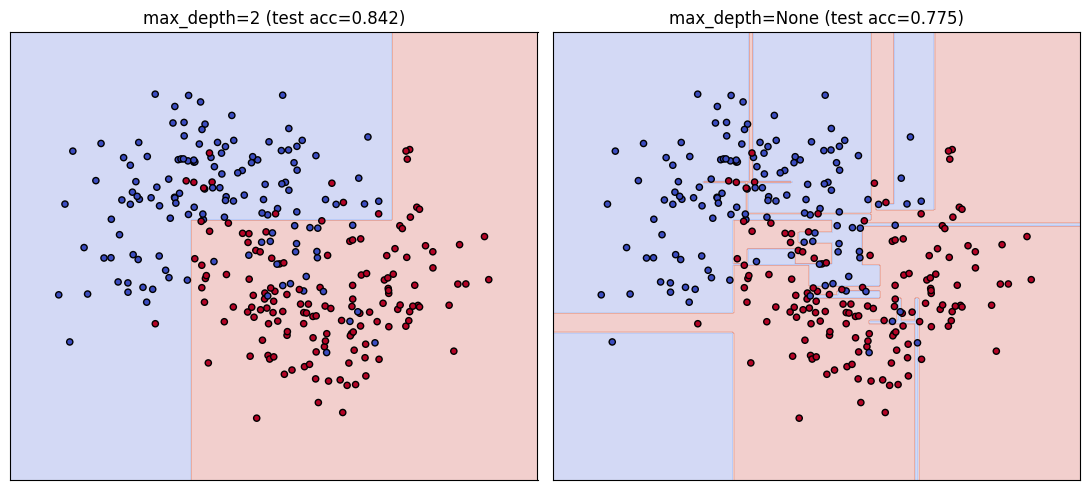

In [3]:
def plot_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=20)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
shallow = DecisionTreeClassifier(max_depth=2, random_state=39).fit(X_train, y_train)
deep = DecisionTreeClassifier(max_depth=None, random_state=39).fit(X_train, y_train)
plot_boundary(shallow, X_train, y_train, axes[0],
              f"max_depth=2 (test acc={shallow.score(X_test, y_test):.3f})")
plot_boundary(deep, X_train, y_train, axes[1],
              f"max_depth=None (test acc={deep.score(X_test, y_test):.3f})")
plt.tight_layout()
plt.show()

*The unconstrained tree's boundary has sharp, isolated pockets carved out around individual
noisy training points — it memorized them (train accuracy 1.000) at the cost of generalization
(test accuracy actually LOWER than the shallow tree's). This is notebook 37's bias-variance
tradeoff again: a shallow tree is high-bias (a blunt, blocky boundary) but low-variance; an
unconstrained tree is low-bias but so high-variance that it fits noise.*

## Bagging and Random Forests

Breiman's fix is exactly notebook 37's "learn many models" idea, made concrete: train many
unconstrained (high-variance) trees, each on a different **bootstrap** resample of the training
data, and average their votes. Averaging cancels out each tree's noise-driven mistakes without
reintroducing bias — the same effect we measured on toy polynomials in notebook 37, now on
trees that are individually just as overfit as the one above.

Random forests add one more trick beyond plain bagging: at each split, only a **random subset**
of features is considered, not all of them. This decorrelates the trees — without it, if one
feature is strongly predictive, nearly every bootstrapped tree would split on it first and the
trees would end up similar to each other, which weakens the variance-cancellation effect of
averaging.

In [4]:
single_tree = DecisionTreeClassifier(max_depth=None, random_state=39).fit(X_train, y_train)
print(f"single unconstrained tree: train={single_tree.score(X_train, y_train):.3f} "
      f"test={single_tree.score(X_test, y_test):.3f}")

for n_estimators in [10, 50, 100, 200, 500]:
    forest = RandomForestClassifier(n_estimators=n_estimators, oob_score=True, random_state=39)
    forest.fit(X_train, y_train)
    print(f"forest n_estimators={n_estimators:>4}  train={forest.score(X_train, y_train):.3f}  "
          f"oob={forest.oob_score_:.3f}  test={forest.score(X_test, y_test):.3f}")

single unconstrained tree: train=1.000 test=0.775
forest n_estimators=  10  train=0.986  oob=0.821  test=0.825
forest n_estimators=  50  train=1.000  oob=0.871  test=0.850
forest n_estimators= 100  train=1.000  oob=0.864  test=0.858


forest n_estimators= 200  train=1.000  oob=0.850  test=0.850


forest n_estimators= 500  train=1.000  oob=0.861  test=0.867


*Every individual tree in the forest is exactly as overfit as the single tree above (train
accuracy 1.000) — but averaging their (still-noisy, still-different) mistakes recovers roughly
8 points of test accuracy over the single tree, with no extra data. Notice the `oob` column
tracks `test` closely at every forest size, without ever touching `X_test`/`y_test` — that's
next.*

## Out-of-bag error: a validation set you already paid for

Each tree only trains on a bootstrap sample — draws *with replacement* from the training set.
On average, about `1 - 1/e ≈ 63%` of the training points end up in any given tree's bootstrap
sample; the remaining **37% are "out-of-bag" for that tree** — never seen during its training.
For any training point, the trees that didn't see it can vote on it as if it were held-out
data. Aggregate this across all points and you get the OOB score: a validation estimate
computed entirely from data the forest already had, no separate split required.

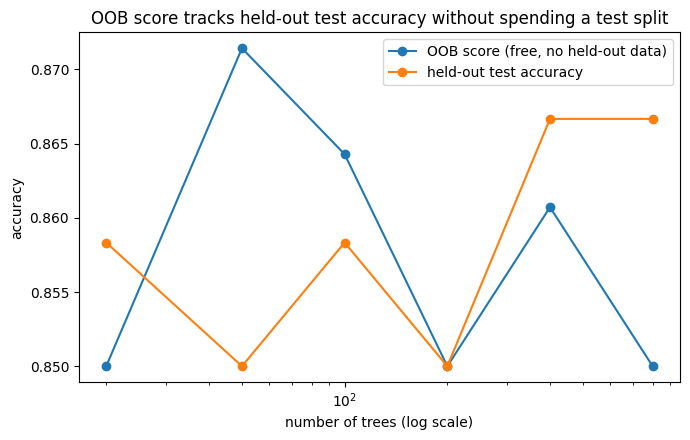

In [5]:
n_range = [20, 50, 100, 200, 400, 800]
oob_scores, test_scores = [], []
for n in n_range:
    forest = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=39)
    forest.fit(X_train, y_train)
    oob_scores.append(forest.oob_score_)
    test_scores.append(forest.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(n_range, oob_scores, marker="o", label="OOB score (free, no held-out data)")
ax.plot(n_range, test_scores, marker="o", label="held-out test accuracy")
ax.set_xscale("log")
ax.set_xlabel("number of trees (log scale)")
ax.set_ylabel("accuracy")
ax.set_title("OOB score tracks held-out test accuracy without spending a test split")
ax.legend()
plt.tight_layout()
plt.show()

*The two curves move together and land in the same range at every forest size — OOB
score is a legitimate, nearly-free proxy for generalization. This matters most when data is
scarce: a small dataset that can't afford to lose 20-30% of its rows to a validation split can
still get an honest generalization estimate for free.*

## Feature importance: which inputs actually mattered?

Because a forest tracks how much each feature reduces impurity across every split, in every
tree, it can rank features by importance — a natural byproduct of training, not an extra step.
Let's add four pure-noise columns to the two real (moon-shaped) features and check that the
forest correctly ranks the real signal above the noise.

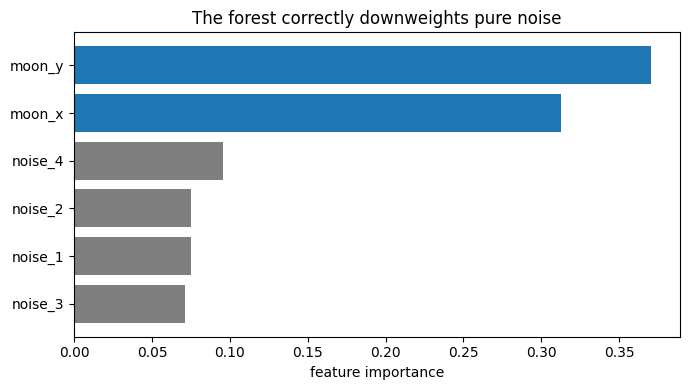

moon_y     importance=0.3705
moon_x     importance=0.3126
noise_4    importance=0.0955
noise_2    importance=0.0752
noise_1    importance=0.0752
noise_3    importance=0.0709


In [6]:
noise_features = rng.normal(0, 1, (len(X), 4))
X_aug = np.hstack([X, noise_features])
feature_names = ["moon_x", "moon_y", "noise_1", "noise_2", "noise_3", "noise_4"]

Xa_train, Xa_test, ya_train, ya_test = train_test_split(X_aug, y, test_size=0.3, random_state=39)
forest_aug = RandomForestClassifier(n_estimators=200, random_state=39).fit(Xa_train, ya_train)

importances = sorted(zip(feature_names, forest_aug.feature_importances_), key=lambda t: -t[1])
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh([n for n, _ in importances][::-1], [v for _, v in importances][::-1],
        color=["tab:blue" if "moon" in n else "tab:gray" for n, _ in importances][::-1])
ax.set_xlabel("feature importance")
ax.set_title("The forest correctly downweights pure noise")
plt.tight_layout()
plt.show()
for name, imp in importances:
    print(f"{name:10s} importance={imp:.4f}")

*The two real features come out roughly 4-5x more important than any noise feature — with
no manual feature selection. This is one of the most-used practical features of tree ensembles:
they double as a feature-relevance report almost for free.*

## Gradient boosting: trees that fix each other's mistakes

Bagging trains trees **independently** and averages them — it reduces variance. Boosting trains
trees **sequentially**, and each new tree is fit not to the original target `y`, but to the
*residual* — how wrong the ensemble-so-far still is. This is functional gradient descent: for
squared-error loss, the negative gradient of the loss with respect to the current prediction is
exactly the residual, so "fit a tree to the residual" and "take a gradient step in function
space" are the same operation. Boosting attacks **bias**, the opposite failure mode from
bagging.

In [7]:
def true_function(x):
    return np.sin(x) * 2.0

N = 60
Xb = rng.uniform(0, 2 * np.pi, N).reshape(-1, 1)
yb = true_function(Xb.ravel()) + rng.normal(0, 0.4, N)
Xb_grid = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
yb_true = true_function(Xb_grid.ravel())

def gradient_boost_fit(X, y, n_rounds, lr=0.1, max_depth=2):
    init = y.mean()
    pred = np.full(len(y), init)
    trees = []
    for _ in range(n_rounds):
        residual = y - pred                       # negative gradient of squared error
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=39)
        tree.fit(X, residual)
        pred = pred + lr * tree.predict(X)
        trees.append(tree)
    return trees, init

def gradient_boost_predict(trees, init, X, lr=0.1):
    pred = np.full(len(X), init)
    for tree in trees:
        pred = pred + lr * tree.predict(X)
    return pred

for n_rounds in [1, 5, 20, 100]:
    trees, init = gradient_boost_fit(Xb, yb, n_rounds)
    test_pred = gradient_boost_predict(trees, init, Xb_grid)
    mse = np.mean((test_pred - yb_true) ** 2)
    print(f"rounds={n_rounds:>4}  test MSE={mse:.4f}")

rounds=   1  test MSE=1.6464
rounds=   5  test MSE=0.7663
rounds=  20  test MSE=0.0818
rounds= 100  test MSE=0.1085


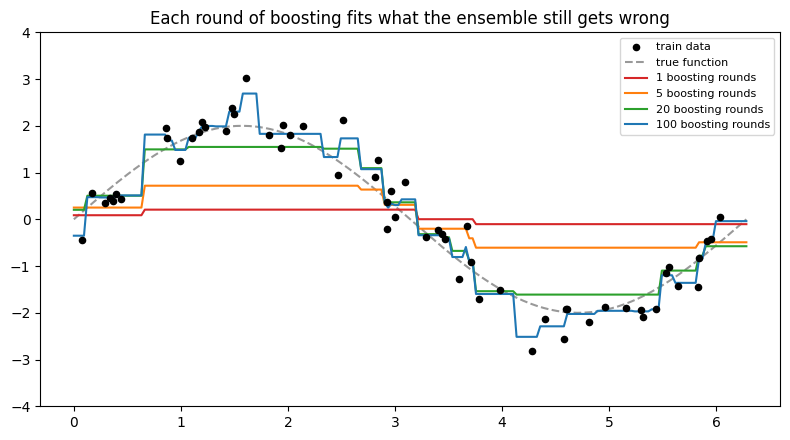

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(Xb, yb, color="black", s=20, zorder=5, label="train data")
ax.plot(Xb_grid, yb_true, "k--", alpha=0.4, label="true function")
for n_rounds, color in zip([1, 5, 20, 100], ["tab:red", "tab:orange", "tab:green", "tab:blue"]):
    trees, init = gradient_boost_fit(Xb, yb, n_rounds)
    pred = gradient_boost_predict(trees, init, Xb_grid)
    ax.plot(Xb_grid, pred, color=color, label=f"{n_rounds} boosting rounds")
ax.set_ylim(-4, 4)
ax.legend(fontsize=8)
ax.set_title("Each round of boosting fits what the ensemble still gets wrong")
plt.tight_layout()
plt.show()

*After 1 round the model is just a single shallow tree — a crude step function. By 100
rounds, dozens of small corrections have stacked into a smooth approximation of the sine curve,
each one specifically targeting the previous ensemble's remaining error. Note this used
`max_depth=2` "stumps" throughout — weak individual learners that only become powerful in
sequence, unlike a random forest's strong-but-independent trees.*

## XGBoost: gradient boosting, engineered

`xgboost` implements the same core idea as the loop above, plus two things that made it the
default for competition and production tabular ML: an explicit **regularization term** in the
objective (penalizing both the number of leaves and the magnitude of leaf weights, directly
fighting the overfitting boosting is otherwise prone to) and a highly optimized, parallelized,
histogram-based split-finding algorithm that scales to millions of rows. Let's measure the
regularization effect directly.

In [9]:
import xgboost as xgb
import time

t0 = time.time()
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                               random_state=39, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
fit_time = time.time() - t0
print(f"xgboost: train={xgb_model.score(X_train, y_train):.3f} "
      f"test={xgb_model.score(X_test, y_test):.3f}  fit time={fit_time*1000:.0f}ms")

print()
print("regularization sweep (deeper trees, reg_lambda varied):")
for reg_lambda in [0, 1, 10, 50]:
    m = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                           reg_lambda=reg_lambda, random_state=39, eval_metric="logloss")
    m.fit(X_train, y_train)
    train_acc, test_acc = m.score(X_train, y_train), m.score(X_test, y_test)
    print(f"reg_lambda={reg_lambda:>3}  train={train_acc:.3f}  test={test_acc:.3f}  "
          f"train-test gap={train_acc - test_acc:.3f}")

xgboost: train=0.961 test=0.867  fit time=235ms

regularization sweep (deeper trees, reg_lambda varied):


reg_lambda=  0  train=1.000  test=0.858  train-test gap=0.142


reg_lambda=  1  train=0.996  test=0.850  train-test gap=0.146


reg_lambda= 10  train=0.943  test=0.858  train-test gap=0.085


reg_lambda= 50  train=0.907  test=0.858  train-test gap=0.049


*Test accuracy stays essentially flat across the sweep, but the train-test gap shrinks from
roughly 0.14 to 0.05 as `reg_lambda` grows — regularization buys a model that's less overfit to
this particular training sample, at no cost to generalization. On noisier or smaller real
datasets than this toy one, that same regularization is often the difference between a model
that generalizes and one that doesn't.*

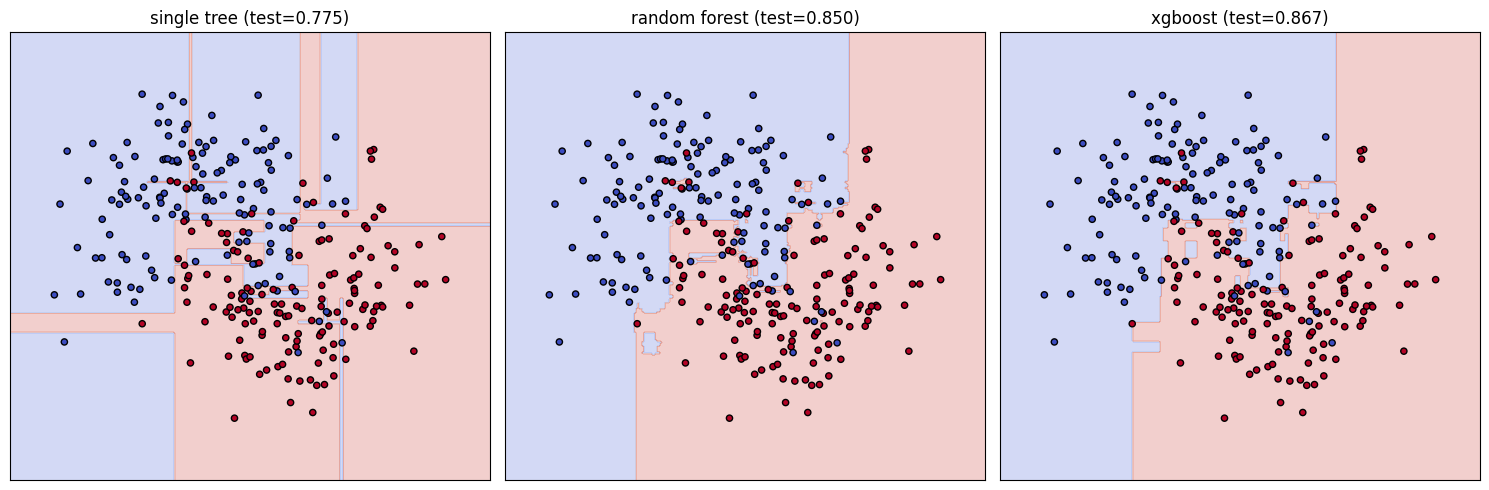

In [10]:
from sklearn.ensemble import RandomForestClassifier as RFC

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
final_tree = DecisionTreeClassifier(max_depth=None, random_state=39).fit(X_train, y_train)
final_forest = RFC(n_estimators=200, random_state=39).fit(X_train, y_train)
plot_boundary(final_tree, X_train, y_train, axes[0],
              f"single tree (test={final_tree.score(X_test, y_test):.3f})")
plot_boundary(final_forest, X_train, y_train, axes[1],
              f"random forest (test={final_forest.score(X_test, y_test):.3f})")
plot_boundary(xgb_model, X_train, y_train, axes[2],
              f"xgboost (test={xgb_model.score(X_test, y_test):.3f})")
plt.tight_layout()
plt.show()

*The single tree's boundary is jagged and pockmarked with noise-driven islands; the forest's
is smoother because it's an average of many such boundaries; xgboost's is smoother still and
achieves the best test accuracy of the three, from an ensemble that took under a quarter of a
second to train.*

## When NOT to reach for an LLM

The moons dataset above has 2-6 numeric columns and 400 rows. XGBoost trained on it in
milliseconds and reached ~87% test accuracy with a handful of lines of code. Framing this same
problem as an LLM classification task — serializing each row into a text prompt, calling an API
per prediction, parsing the response — would mean: per-prediction latency measured in hundreds
of milliseconds to seconds instead of microseconds, a real dollar cost per prediction instead of
effectively free, no calibrated probability output without extra engineering, and very likely
*worse* accuracy, since LLMs are not naturally good at precise numeric decision boundaries the
way a tree split (`x > 0.314`) is. Tree ensembles remain the right default whenever the problem
is: tabular, numeric-or-categorical features, a clear label, and enough rows to train on. LLMs
earn their cost on natural language, unstructured data, and tasks that need reasoning over
context a tree can't represent — not as a universal drop-in classifier.

## Exercises

In [11]:
# Exercise 1 (Warm-up): how many trees is "enough"?
# Task: Using the shared X_train/X_test, plot test accuracy vs n_estimators for
#       RandomForestClassifier over n_estimators in [1, 2, 5, 10, 20, 50, 100, 300]. At what
#       point does adding more trees stop meaningfully improving test accuracy?
# Hint: unlike boosting rounds, more bagged trees can't overfit further — the curve should
#       rise then flatten, never turn back down.

# YOUR CODE HERE

In [12]:
# Exercise 2 (Apply): implement bagging from scratch (no sklearn ensemble)
# Task: Without using RandomForestClassifier, write bagged_predict(X_train, y_train, X_query,
#       n_trees) that fits n_trees separate DecisionTreeClassifier(max_depth=None) models, each
#       on its own bootstrap resample (np.random sampling WITH replacement, same size as
#       X_train), and returns the majority vote across trees for each row of X_query. Confirm
#       its test accuracy lands close to RandomForestClassifier's (it won't match exactly —
#       sklearn's forest also subsamples FEATURES per split, which yours doesn't).
# Hint: rng.integers(0, len(X_train), len(X_train)) gives one bootstrap's row indices.

# YOUR CODE HERE

In [13]:
# Exercise 3 (Extend): connect boosting's residual-fitting to notebook 38's gradient descent
# Task: gradient_boost_fit above fits each new tree to `y - pred`, the residual under SQUARED
#       error loss. For a general differentiable loss L(y, pred), the "residual" a boosting
#       round should fit is actually -dL/dpred (the negative gradient), which for squared error
#       IS (y - pred). Write the negative gradient for absolute error loss L = |y - pred|
#       instead (it's a sign, not a magnitude), and explain in a comment why boosting on THAT
#       target would make each tree robust to outliers in a way squared-error boosting isn't.
# Hint: d|y-pred|/dpred is +/-1 depending on the sign of (pred - y) — the gradient literally
#       ignores HOW wrong a point is, only whether the prediction was too high or too low.

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
n_range_ex1 = [1, 2, 5, 10, 20, 50, 100, 300]
accs = []
for n in n_range_ex1:
    f = RandomForestClassifier(n_estimators=n, random_state=39).fit(X_train, y_train)
    accs.append(f.score(X_test, y_test))
plt.plot(n_range_ex1, accs, marker="o")
plt.xscale("log"); plt.xlabel("n_estimators"); plt.ylabel("test accuracy"); plt.show()
# Accuracy rises quickly and is essentially flat by n_estimators=50-100 on this dataset —
# beyond that, more trees mainly reduce the VARIANCE of the accuracy estimate itself, not the
# model's actual error, since averaging more independent votes converges with diminishing returns.

# Exercise 2
def bagged_predict(X_train, y_train, X_query, n_trees, seed=39):
    local_rng = np.random.default_rng(seed)
    votes = np.zeros((n_trees, len(X_query)))
    for i in range(n_trees):
        idx = local_rng.integers(0, len(X_train), len(X_train))
        tree = DecisionTreeClassifier(max_depth=None, random_state=seed + i)
        tree.fit(X_train[idx], y_train[idx])
        votes[i] = tree.predict(X_query)
    return (votes.mean(axis=0) >= 0.5).astype(int)

preds = bagged_predict(X_train, y_train, X_test, n_trees=200)
print(f"from-scratch bagging test accuracy: {(preds == y_test).mean():.3f}")
# Should land within a few points of RandomForestClassifier's ~0.85-0.87 — the remaining gap is
# exactly sklearn's per-split feature subsampling, which decorrelates trees further than
# bootstrapping rows alone.

# Exercise 3
def negative_gradient_absolute_error(y, pred):
    return np.sign(y - pred)  # +1, -1, or 0 — NOT (y - pred) itself
# Squared-error boosting fits (y - pred): a point that's off by 10 pulls the next tree ten times
# harder than a point that's off by 1. A single extreme outlier can dominate every subsequent
# round. Absolute-error boosting fits sign(y - pred): every misclassified-direction point pulls
# equally hard regardless of HOW wrong it is, so one outlier can't hijack the correction the way
# it can under squared error — the same robust-vs-sensitive tradeoff between L1 and L2 losses
# that shows up throughout ML, here expressed as "what should the next tree in the ensemble
# actually try to fix."
```
</details>

## Key Takeaways
- **A single unconstrained tree overfits exactly like a high-degree polynomial** (notebook 37) — perfect training accuracy, worse test accuracy than a constrained model.
- **Random forests are notebook 37's "average many models" idea, applied to trees**: bagging (bootstrap resampling) plus per-split feature subsampling decorrelates the trees so averaging actually cancels variance.
- **Out-of-bag error is a validation estimate you get for free** — no separate held-out split required, and it tracks true test accuracy closely.
- **Boosting is the opposite lever from bagging**: sequential trees fitting residuals attack bias, not variance, and are functional gradient descent under the hood.
- **XGBoost's edge is regularization plus engineering**, not a different core algorithm — and tree ensembles remain the right default for tabular, numeric, clearly-labeled prediction problems, not LLMs.

## What's Next
Notebook 40 turns from *which model* to *how you wire it up correctly* — the scikit-learn `Pipeline` API exists specifically to prevent the kind of data leakage that makes an overfit model look fine until it reaches production.